# NER + TF-IDF Analysis
Named Entity Recognition combined with TF-IDF entity weighting for Trump Tariff news articles.

## 1. Setup — Install & Imports

In [2]:
!pip install transformers -q

import pandas as pd
import numpy as np
from transformers import pipeline
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import defaultdict
import json
import time
import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load NER Model

In [3]:
MODEL_NAME = "cahya/bert-base-indonesian-NER"

print(f"Loading model: {MODEL_NAME} ...")
ner = pipeline(
    "ner",
    model=MODEL_NAME,
    aggregation_strategy="first",
)

Loading model: cahya/bert-base-indonesian-NER ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 24384.78it/s]
[transformers] BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 3. Load Dataset

In [4]:
CSV_PATH = "C:\IBU yg LUHUR\Project\kelompok-7-pba\preprocessed\dataset_preprocessed_bert.csv"  # update path if running locally

df = pd.read_csv(CSV_PATH)

TEXT_COL = "konten_preprocessed"

df = df.dropna(subset=[TEXT_COL]).reset_index(drop=True)

print(f"Loaded {len(df):,} articles")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

<>:1: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
<>:1: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
C:\Users\ZHINI\AppData\Local\Temp\ipykernel_37904\2411020645.py:1: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
  CSV_PATH = "C:\IBU yg LUHUR\Project\kelompok-7-pba\preprocessed\dataset_preprocessed_bert.csv"  # update path if running locally


Loaded 999 articles
Columns: ['url', 'judul', 'konten', 'manual sentiment', 'konten_length', 'konten_preprocessed']


,url,judul,konten,manual sentiment,konten_length,konten_preprocessed
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,8328,jakarta cnbc indonesia amerika serikat as seca...
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2925,jakarta cnbc indonesia nilai tukar rupiah terh...
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,13102,jakarta cnbc indonesia pasar keuangan indonesi...


## 4. Helper — Clean & Run NER

In [5]:
SKIP_TOKENS = {".", ",", "%", "(", ")", "-", "/", "'", '"'}
MAX_CHARS = 1500


def clean_entities(raw_entities: list) -> list:
    cleaned = []
    seen = set()

    for ent in raw_entities:
        word = ent["word"].strip().strip(".,")

        if not word or word in SKIP_TOKENS:
            continue
        if len(word) <= 1:
            continue

        label = ent["entity_group"]
        key = (word.lower(), label)

        cleaned.append({
            "word": word,
            "entity_group": label,
            "score": round(float(ent["score"]), 4),
            "start": ent.get("start"),
            "end": ent.get("end"),
            "is_duplicate": key in seen,
        })
        seen.add(key)

    return cleaned


def run_ner(text: str) -> list:
    if not isinstance(text, str) or not text.strip():
        return []
    try:
        truncated = text[:MAX_CHARS]
        raw = ner(truncated)
        return clean_entities(raw)
    except Exception as exc:
        print(f"  ⚠️  NER error: {exc}")
        return []


def display_entities(entities: list, title: str = ""):
    if title:
        print(f"\n{'='*60}")
        print(f"  {title}")
        print(f"{'='*60}")

    unique = [e for e in entities if not e["is_duplicate"]]
    print(f"{'Word':<35} | {'Label':<8} | {'Score'}")
    print("-" * 55)
    for ent in unique:
        print(f"{ent['word']:<35} | {ent['entity_group']:<8} | {ent['score']:.4f}")
    print(f"\n  → {len(unique)} unique entities found")

## 5. Single-Article Test (Sanity Check)

In [6]:
TEST_IDX = 0

test_row = df.iloc[TEST_IDX]
test_text = test_row[TEXT_COL]

print(f"Article index : {TEST_IDX}")
print(f"Title         : {test_row.get('judul', 'N/A')}")
print(f"Text length   : {len(test_text):,} chars (truncated to {MAX_CHARS} for NER)")
print(f"\nText preview  :\n{test_text[:400]}\n{'...' if len(test_text) > 400 else ''}")

test_entities = run_ner(test_text)
display_entities(test_entities, title=f"NER Results — Article {TEST_IDX}")

Article index : 0
Title         : Trump Sebar Exceutive Order: Emang Semengerikan Apa Buat Indonesia? - CNBC Indonesia
Text length   : 7,996 chars (truncated to 1500 for NER)

Text preview  :
jakarta cnbc indonesia amerika serikat as secara resmi memiliki presiden baru yang disambut positif karena agenda pro bisnis yang dibawanya presiden amerika serikat as donald trump resmi dilantik pada senin waktu as secara umum dalam pidatonya trump mengungkapkan kebijakan perdagangan proteksionis yang sebelumnya dikhawatirkan akan dilakukan secara agresif tampaknya akan diterapkan lebih terukur t
...

  NER Results — Article 0
Word                                | Label    | Score
-------------------------------------------------------
jakarta                             | ORG      | 0.4804
cnbc indonesia                      | ORG      | 0.6007
amerika serikat as                  | NOR      | 0.4990
presiden amerika serikat as         | NOR      | 0.9504
donald trump                        | PER

## 6. Full Dataset NER Run

In [ ]:
all_results = []
error_indices = []

start_time = time.time()

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Running NER"):
    text = row[TEXT_COL]
    entities = run_ner(text)

    if not entities:
        error_indices.append(idx)

    for ent in entities:
        all_results.append({
            "article_idx"  : idx,
            "judul"        : row.get("judul"),
            "url"          : row.get("url"),
            "word"         : ent["word"],
            "entity_group" : ent["entity_group"],
            "score"        : ent["score"],
            "is_duplicate" : ent["is_duplicate"],
            "start"        : ent["start"],
            "end"          : ent["end"],
        })

elapsed = time.time() - start_time
print(f"\n Done in {elapsed:.1f}s")
print(f"   Articles processed       : {len(df):,}")
print(f"   Total entities           : {len(all_results):,}")
print(f"   Articles with no entities: {len(error_indices)}")

results_df = pd.DataFrame(all_results)

Running NER: 100%|██████████| 999/999 [07:02<00:00,  2.37it/s]


✅ Done in 422.0s
   Articles processed       : 999
   Total entities           : 28,783
   Articles with no entities: 0


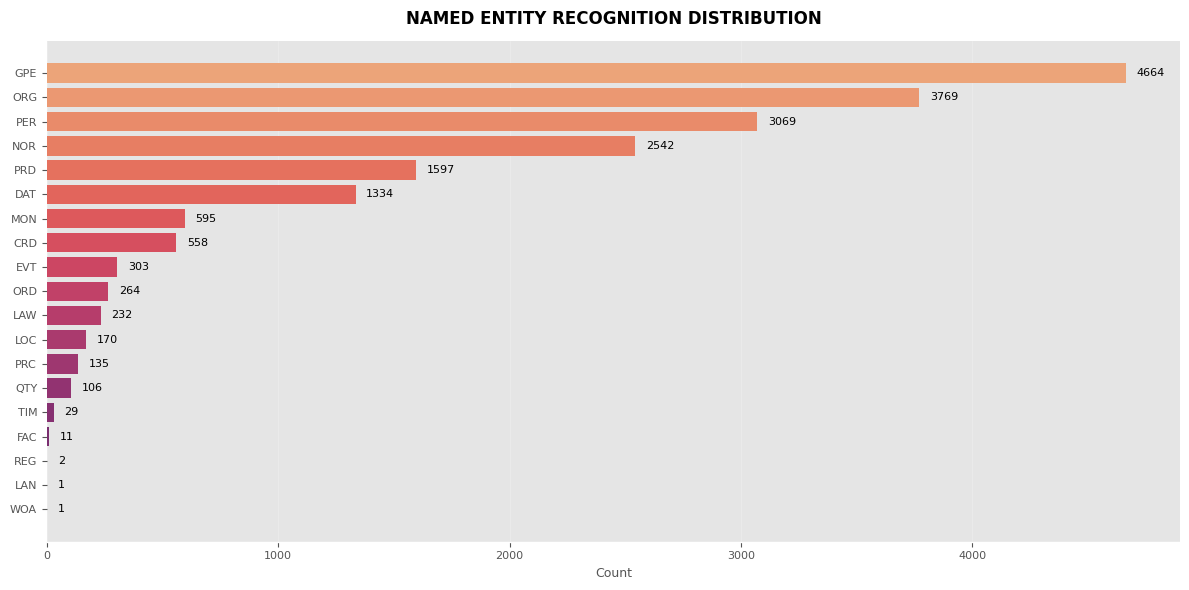

In [ ]:
# Data
label_counts = (
    results_df[~results_df["is_duplicate"]]["entity_group"]
    .value_counts()
)

plt.style.use("ggplot")  
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("flare", len(label_counts))

# Plot
bars = ax.barh(
    label_counts.index[::-1],
    label_counts.values[::-1],
    color=colors[::-1]
)

# Title
ax.set_title("NAMED ENTITY RECOGNITION DISTRIBUTION",
             fontsize=12, weight="bold", pad=12)

# Label 
ax.set_xlabel("Count", fontsize=9)
ax.set_ylabel("")

# Grid 
ax.grid(axis="x", linestyle="-", linewidth=0.5, alpha=0.3)
ax.grid(axis="y", visible=False)

# Remove spines 
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

# Tick 
ax.tick_params(axis='both', labelsize=8)

# Annotate 
for i, v in enumerate(label_counts.values[::-1]):
    ax.text(v + max(label_counts.values)*0.01, i,
            f"{v}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 7. TF-IDF on Extracted Entities

Step 1: Build entity documents

In [ ]:
unique_results = results_df[~results_df["is_duplicate"]]

entity_docs = (
    unique_results
    .groupby("article_idx")["word"]
    .apply(lambda x: " ".join(x.str.lower()))
    .reindex(df.index, fill_value="")   # langsung align ke df
)

print(f"Built {len(entity_docs)} entity documents")
print("Sample:", entity_docs.iloc[0])

Step 2: TF-IDF

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=200,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

tfidf_matrix = vectorizer.fit_transform(entity_docs)
feature_names = vectorizer.get_feature_names_out()

print("TF-IDF shape:", tfidf_matrix.shape)

Step 3: Mean TF-IDF

In [ ]:
tfidf_df = pd.DataFrame({
    "entity": feature_names,
    "mean_tfidf": tfidf_matrix.mean(axis=0).A1
}).sort_values("mean_tfidf", ascending=False)

print(tfidf_df.head(20).to_string(index=False))

## 8. Combine NER Frequency + TF-IDF Score

In [46]:
# ── Entity frequency from NER ───────────────────────────────────────────────
entity_freq = (
    unique_results
    .groupby(["word", "entity_group"])
    .size()
    .reset_index(name="frequency")
)
entity_freq["word_lower"] = entity_freq["word"].str.lower()

# ── Merge with TF-IDF scores ─────────────────────────────────────────────────
combined_df = entity_freq.merge(
    tfidf_df.rename(columns={"entity": "word_lower"}),
    on="word_lower",
    how="left"
).fillna(0)

# ── Compute combined importance score ────────────────────────────────────────
# Normalize frequency to 0-1 scale
combined_df["freq_normalized"] = (
    combined_df["frequency"] / combined_df["frequency"].max()
)

# Combined score = average of normalized frequency + TF-IDF
# This rewards entities that are BOTH frequent AND contextually distinctive
combined_df["combined_score"] = (
    combined_df["freq_normalized"] + combined_df["mean_tfidf"]
) / 2

combined_df = combined_df.sort_values("combined_score", ascending=False)

print("Top 20 entities by Combined Score (Frequency + TF-IDF):")
print(combined_df[["word", "entity_group", "frequency", "mean_tfidf", "combined_score"]]
      .head(20)
      .to_string(index=False))

Top 20 entities by Combined Score (Frequency + TF-IDF):
                       word entity_group  frequency  mean_tfidf  combined_score
                         as          GPE        818    0.115206        0.557603
                      trump          PER        686    0.115784        0.477207
               donald trump          PER        667    0.000000        0.407702
                  indonesia          GPE        397    0.091510        0.288420
                      china          GPE        359    0.066923        0.252899
                    amerika          GPE        284    0.099235        0.223212
                    jakarta          GPE        273    0.065613        0.199677
            amerika serikat          GPE        316    0.000000        0.193154
                 pemerintah          NOR        227    0.055583        0.166545
                      april          DAT        222    0.055871        0.163632
                   presiden          NOR        145    0.085429 

## 9. Per Entity-Type Analysis

In [47]:
# ── Top entities per label type with TF-IDF scores ──────────────────────────
for label in combined_df["entity_group"].unique():
    subset = combined_df[combined_df["entity_group"] == label].head(10)
    print(f"\n{'='*60}")
    print(f"  Top 10 [{label}] entities by combined score")
    print(f"{'='*60}")
    print(subset[["word", "frequency", "mean_tfidf", "combined_score"]]
          .to_string(index=False))


  Top 10 [GPE] entities by combined score
           word  frequency  mean_tfidf  combined_score
             as        818    0.115206        0.557603
      indonesia        397    0.091510        0.288420
          china        359    0.066923        0.252899
        amerika        284    0.099235        0.223212
        jakarta        273    0.065613        0.199677
amerika serikat        316    0.000000        0.193154
         kanada        146    0.035455        0.106970
        serikat         78    0.090259        0.092807
        meksiko        124    0.031696        0.091643
          eropa        108    0.039229        0.085629

  Top 10 [PER] entities by combined score
              word  frequency  mean_tfidf  combined_score
             trump        686    0.115784        0.477207
      donald trump        667    0.000000        0.407702
            donald         77    0.080866        0.087499
                as          2    0.115206        0.058825
          presiden 

## 10. Frequency vs TF-IDF Insight (High Freq but Low TF-IDF)

In [ ]:
# Entities that appear often but have LOW TF-IDF are 'expected' entities
# — they appear in nearly every article, so they carry less analytical value

high_freq_threshold = combined_df["frequency"].quantile(0.75)
low_tfidf_threshold = combined_df["mean_tfidf"].quantile(0.25)

ubiquitous_entities = combined_df[
    (combined_df["frequency"] >= high_freq_threshold) &
    (combined_df["mean_tfidf"] <= low_tfidf_threshold)
].sort_values("frequency", ascending=False)

print("Entities with HIGH frequency but LOW TF-IDF (ubiquitous/expected entities):")
print("These appear in most articles — expected background noise of tariff coverage")
print(ubiquitous_entities[["word", "entity_group", "frequency", "mean_tfidf"]]
      .head(15)
      .to_string(index=False))

print("\n" + "="*60)

# Entities with LOW frequency but HIGH TF-IDF are 'distinctive' entities
# — they appear in fewer articles but carry strong contextual significance
low_freq_threshold = combined_df["frequency"].quantile(0.25)
high_tfidf_threshold = combined_df["mean_tfidf"].quantile(0.75)

distinctive_entities = combined_df[
    (combined_df["frequency"] <= low_freq_threshold) &
    (combined_df["mean_tfidf"] >= high_tfidf_threshold)
].sort_values("mean_tfidf", ascending=False)

print("\nEntities with LOW frequency but HIGH TF-IDF (distinctive/event-specific entities):")
print("These appear in fewer articles but mark specific events or developments")
print(distinctive_entities[["word", "entity_group", "frequency", "mean_tfidf"]]
      .head(15)
      .to_string(index=False))

Entities with HIGH frequency but LOW TF-IDF (ubiquitous/expected entities):
These appear in most articles — expected background noise of tariff coverage
                       word entity_group  frequency  mean_tfidf
               donald trump          PER        667         0.0
            amerika serikat          GPE        316         0.0
presiden amerika serikat as          NOR        207         0.0
                presiden as          NOR        192         0.0
   presiden amerika serikat          NOR        144         0.0
             cnbc indonesia          ORG        121         0.0
         amerika serikat as          GPE         75         0.0
         airlangga hartarto          PER         50         0.0
       pemerintah indonesia          NOR         49         0.0
               gedung putih          ORG         41         0.0
           tempo co jakarta          ORG         41         0.0
                  uni eropa          GPE         34         0.0
               

## 11. Visualizations

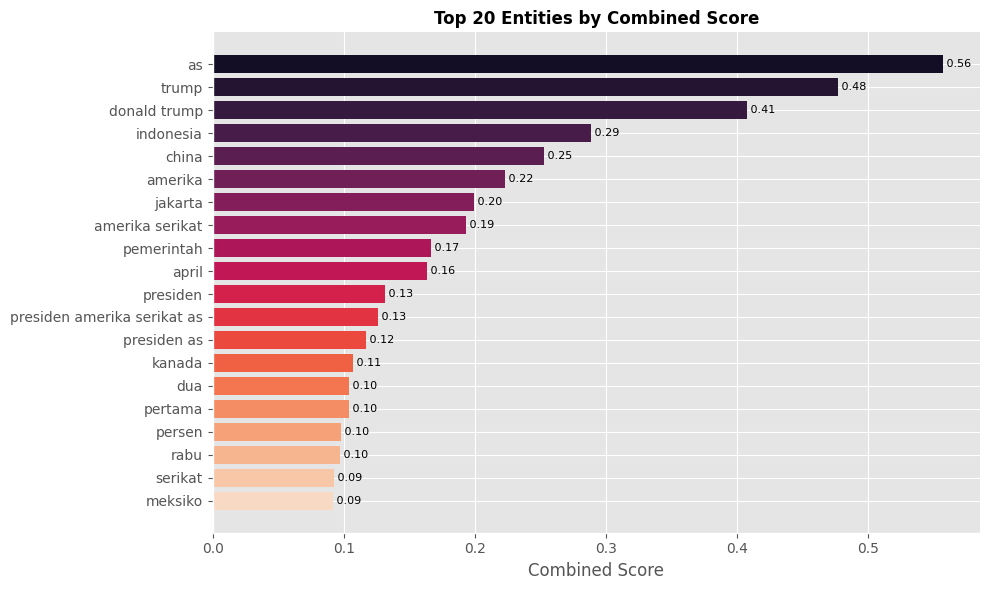

In [ ]:
# Top 20
top20 = combined_df.head(20)

colors = sns.color_palette("rocket", len(top20))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top20["word"][::-1],
    top20["combined_score"][::-1],
    color=colors[::-1]
)
ax.set_title("Top 20 Entities by Combined Score", fontsize=12, weight="bold")
ax.set_xlabel("Combined Score")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Annotate
for i, v in enumerate(top20["combined_score"][::-1]):
    ax.text(v, i, f" {v:.2f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

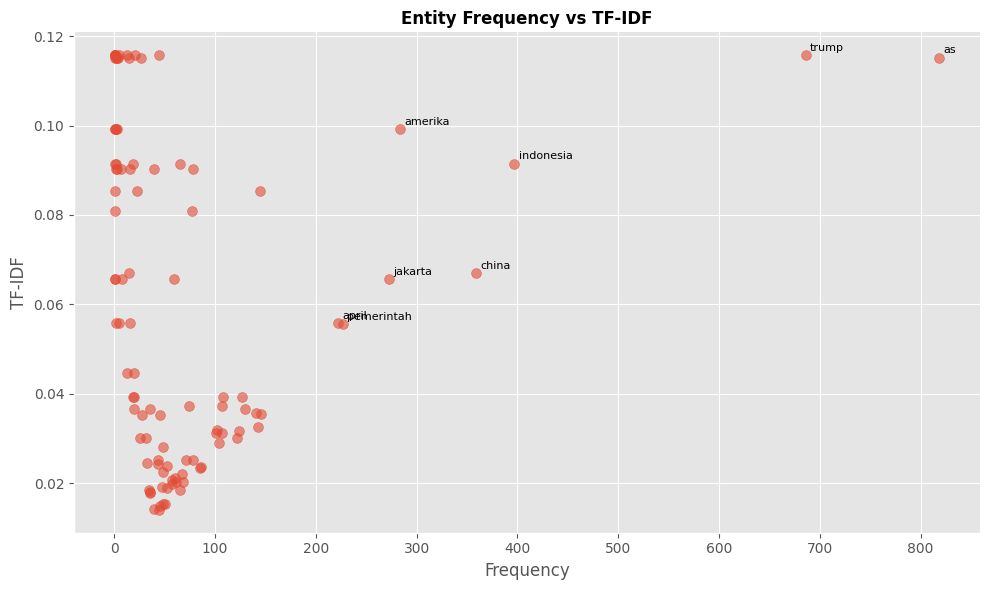

In [50]:
scatter_data = combined_df[combined_df["mean_tfidf"] > 0].head(100)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    scatter_data["frequency"],
    scatter_data["mean_tfidf"],
    alpha=0.6,
    s=50
)

# Annotate top entities
for _, row in combined_df.head(10).iterrows():
    if row["mean_tfidf"] > 0:
        ax.annotate(
            row["word"],
            (row["frequency"], row["mean_tfidf"]),
            fontsize=8,
            xytext=(3, 3),
            textcoords="offset points"
        )

ax.set_title("Entity Frequency vs TF-IDF", fontsize=12, weight="bold")
ax.set_xlabel("Frequency")
ax.set_ylabel("TF-IDF")

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 12. Export Results

In [ ]:
# ── Export 1: Combined NER + TF-IDF scores ───────────────────────────────────
COMBINED_CSV = "../outputs/ner/ner_tfidf_combined.csv"
combined_df.to_csv(COMBINED_CSV, index=False)
print(f"Combined results saved → {COMBINED_CSV}")

# ── Export 2: Per-article summary ─────────────────────────────────
unique_df = results_df[~results_df["is_duplicate"]].copy()

unique_df["entity_record"] = unique_df.apply(
    lambda r: {"word": r["word"], "entity_group": r["entity_group"], "score": round(float(r["score"]), 4)},
    axis=1
)

summary_df = (
    unique_df
    .groupby(["article_idx", "judul", "url"], as_index=False, dropna=False)["entity_record"]
    .agg(list)
    .rename(columns={"entity_record": "entities"})
)

summary_df["entity_count"] = summary_df["entities"].apply(len)
summary_df["entities_json"] = summary_df["entities"].apply(json.dumps)

SUMMARY_CSV = "../outputs/ner/ner_results_summary.csv"
summary_df.drop(columns=["entities"]).to_csv(SUMMARY_CSV, index=False)
print(f"Summary saved → {SUMMARY_CSV}  ({len(summary_df):,} articles)")

# ── Export 3: TF-IDF scores only ─────────────────────────────────────────────
TFIDF_CSV = "../outputs/ner/entity_tfidf_scores.csv"
tfidf_df.to_csv(TFIDF_CSV, index=False)
print(f"TF-IDF scores saved → {TFIDF_CSV}")

print("\n✅ All exports complete")
summary_df.drop(columns=["entities_json"]).head(5)